# Data Cleaning Notebook

Week 1-2 stuff

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
np.random.seed(42)


In [2]:
SRC_PATH = Path.cwd() / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from project_utils import (
    EXPECTED_AUDIO_COLS,
    clean_spotify_dataframe,
    ensure_dir,
    get_numeric_model_frame,
    load_spotify_dataframe,
    split_data,
)


In [3]:
raw_df, source_path = load_spotify_dataframe(data_dir="data", allow_download=True)
print(f"Loaded dataset from: {source_path}")
print(f"Raw shape: {raw_df.shape}")
raw_df.head()


Loaded dataset from: data/processed/spotify_clean.csv
Raw shape: (130371, 17)


,artist_name,track_id,track_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,popularity
0,YG,2RM4jf1Xa9zPgMGRDiht8O,"Big Bank feat. 2 Chainz, Big Sean, Nicki Minaj",0.005820,0.743,238373,0.339,0.000,1,0.0812,-7.678,1,0.4090,203.927,4,0.118,15
1,YG,1tHDG53xJNGsItRA3vfVgs,BAND DRUM (feat. A$AP Rocky),0.024400,0.846,214800,0.557,0.000,8,0.2860,-7.259,1,0.4570,159.009,4,0.371,0
2,R3HAB,6Wosx2euFPMT14UXiWudMy,Radio Silence,0.025000,0.603,138913,0.723,0.000,9,0.0824,-5.890,0,0.0454,114.966,4,0.382,56
3,Chris Cooq,3J2Jpw61sO7l6Hc7qdYV91,Lactose,0.029400,0.800,125381,0.579,0.912,5,0.0994,-12.118,0,0.0701,123.003,4,0.641,0
4,Chris Cooq,2jbYvQCyPgX3CdmAzeVeuS,Same - Original mix,0.000035,0.783,124016,0.792,0.878,7,0.0332,-10.277,1,0.0661,120.047,4,0.928,0


In [4]:
print("Raw columns:")
print(raw_df.columns.tolist())

missing_report = raw_df.isna().mean().sort_values(ascending=False).head(15)
print()
print("Top missing-value rates:")
print((missing_report * 100).round(2).astype(str) + "%")


Raw columns:
['artist_name', 'track_id', 'track_name', 'acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence', 'popularity']

Top missing-value rates:
track_name          0.0%
artist_name         0.0%
liveness            0.0%
valence             0.0%
time_signature      0.0%
tempo               0.0%
speechiness         0.0%
mode                0.0%
loudness            0.0%
key                 0.0%
track_id            0.0%
instrumentalness    0.0%
energy              0.0%
duration_ms         0.0%
danceability        0.0%
dtype: object


In [5]:
clean_df = clean_spotify_dataframe(raw_df)
model_df = get_numeric_model_frame(clean_df)

print(f"Rows before cleaning: {len(raw_df):,}")
print(f"Rows after cleaning:  {len(clean_df):,}")
print(f"Numeric modeling columns: {len(model_df.columns)}")

proposal_cols_available = [c for c in EXPECTED_AUDIO_COLS if c in clean_df.columns]
print()
print("Proposal-aligned columns available:")
print(proposal_cols_available)

clean_df.head()


Rows before cleaning: 130,371
Rows after cleaning:  130,371
Numeric modeling columns: 14

Proposal-aligned columns available:
['danceability', 'energy', 'valence', 'acousticness', 'loudness', 'tempo', 'speechiness', 'instrumentalness', 'liveness', 'popularity']


,artist_name,track_id,track_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,popularity
0,YG,2RM4jf1Xa9zPgMGRDiht8O,"Big Bank feat. 2 Chainz, Big Sean, Nicki Minaj",0.005820,0.743,238373,0.339,0.000,1,0.0812,-7.678,1,0.4090,203.927,4,0.118,15
1,YG,1tHDG53xJNGsItRA3vfVgs,BAND DRUM (feat. A$AP Rocky),0.024400,0.846,214800,0.557,0.000,8,0.2860,-7.259,1,0.4570,159.009,4,0.371,0
2,R3HAB,6Wosx2euFPMT14UXiWudMy,Radio Silence,0.025000,0.603,138913,0.723,0.000,9,0.0824,-5.890,0,0.0454,114.966,4,0.382,56
3,Chris Cooq,3J2Jpw61sO7l6Hc7qdYV91,Lactose,0.029400,0.800,125381,0.579,0.912,5,0.0994,-12.118,0,0.0701,123.003,4,0.641,0
4,Chris Cooq,2jbYvQCyPgX3CdmAzeVeuS,Same - Original mix,0.000035,0.783,124016,0.792,0.878,7,0.0332,-10.277,1,0.0661,120.047,4,0.928,0


In [6]:
train_df, val_df, test_df = split_data(model_df, test_size=0.15, val_size=0.15, random_state=42)

processed_dir = ensure_dir("data/processed")
clean_path = processed_dir / "spotify_clean.csv"
train_path = processed_dir / "train.csv"
val_path = processed_dir / "val.csv"
test_path = processed_dir / "test.csv"

clean_df.to_csv(clean_path, index=False)
train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)

print(f"Saved: {clean_path}")
print(f"Saved: {train_path}")
print(f"Saved: {val_path}")
print(f"Saved: {test_path}")
print()
print(f"Split sizes -> train: {len(train_df):,}, val: {len(val_df):,}, test: {len(test_df):,}")


Saved: data/processed/spotify_clean.csv
Saved: data/processed/train.csv
Saved: data/processed/val.csv
Saved: data/processed/test.csv

Split sizes -> train: 91,259, val: 19,556, test: 19,556


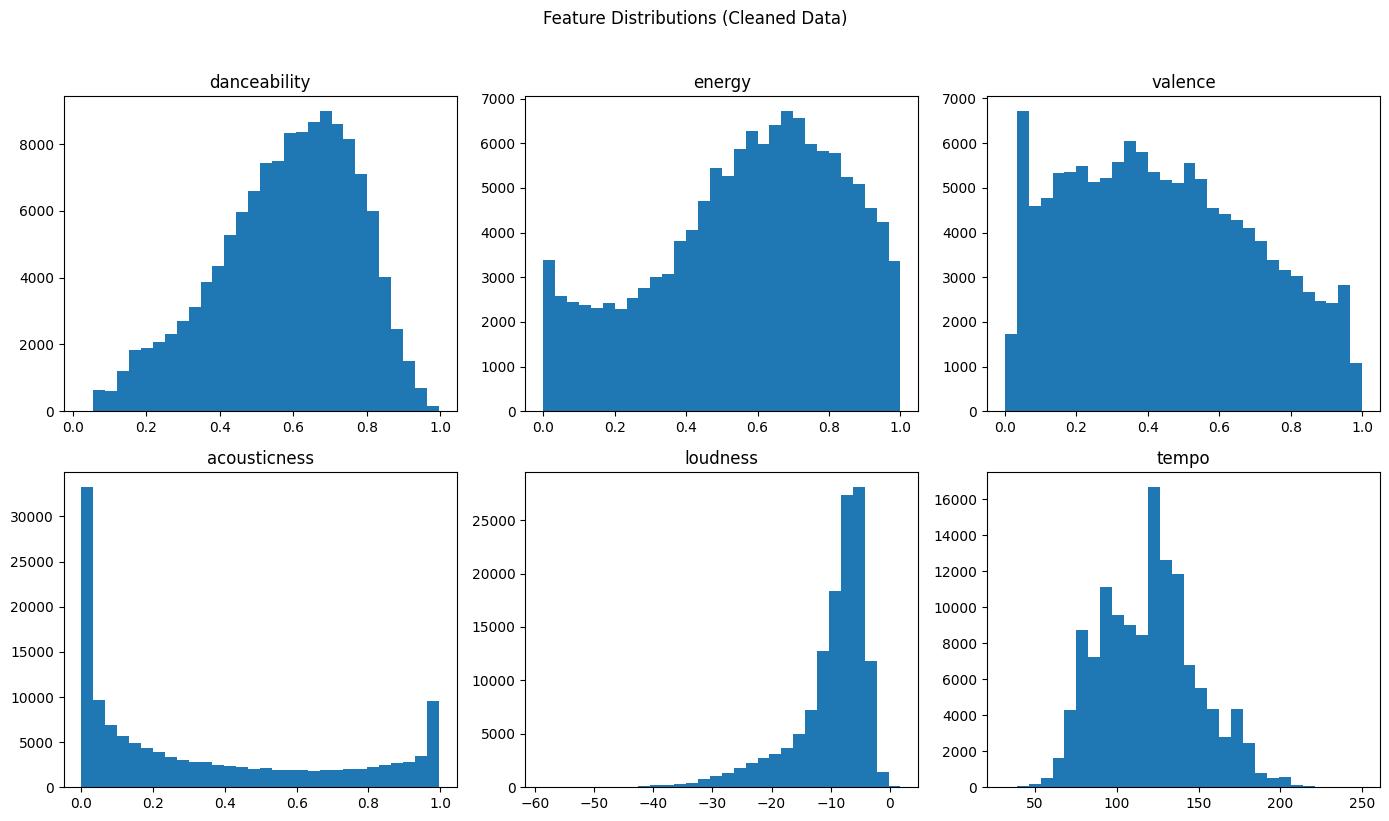

In [7]:
plot_cols = [
    c for c in ["danceability", "energy", "valence", "acousticness", "loudness", "tempo"]
    if c in model_df.columns
]

if plot_cols:
    n_cols = 3
    n_rows = int(np.ceil(len(plot_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(plot_cols):
        axes[i].hist(model_df[col], bins=30)
        axes[i].set_title(col)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Feature Distributions (Cleaned Data)", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No proposal columns found for plotting.")
